In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch


current_path = Path.cwd()

PROJECT_ROOT = None

for path in [current_path, *current_path.parents]:
    if (path / "data" / "processed").exists() and (path / "models").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "UrbanFlow project root could not be located."
    )

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"


SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


N_SENSORS = 207
INPUT_STEPS = 12
WEATHER_FEATURES = 6
HORIZONS = [15, 30, 45, 60]


print("=" * 70)
print("URBANFLOW — FINAL INTEGRATED MODEL")
print("=" * 70)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_DIR}")
print(f"Model folder : {MODEL_DIR}")
print(f"Results      : {RESULTS_DIR}")
print(f"Device       : {DEVICE}")

print("\nFinal architecture:")
print("  GNN → Spatial Learning")
print("  Transformer → Temporal Learning")
print("  Weather → Environmental Context")
print("  Multi-Horizon → 15 / 30 / 45 / 60 minutes")

print("\nConfiguration:")
print(f"  Sensors          : {N_SENSORS}")
print(f"  Input timesteps  : {INPUT_STEPS}")
print(f"  Weather features : {WEATHER_FEATURES}")
print(f"  Horizons         : {HORIZONS}")

print("\nSetup verified successfully.")
print("=" * 70)

URBANFLOW — FINAL INTEGRATED MODEL
Project root : /Users/raginigupta/Desktop/Urbanflow
Data folder  : /Users/raginigupta/Desktop/Urbanflow/data/processed
Model folder : /Users/raginigupta/Desktop/Urbanflow/models
Results      : /Users/raginigupta/Desktop/Urbanflow/results
Device       : mps

Final architecture:
  GNN → Spatial Learning
  Transformer → Temporal Learning
  Weather → Environmental Context
  Multi-Horizon → 15 / 30 / 45 / 60 minutes

Configuration:
  Sensors          : 207
  Input timesteps  : 12
  Weather features : 6
  Horizons         : [15, 30, 45, 60]

Setup verified successfully.


In [2]:

required_files = {
    "Train sequences": DATA_DIR / "train_sequences.npz",
    "Validation sequences": DATA_DIR / "validation_sequences.npz",
    "Test sequences": DATA_DIR / "test_sequences.npz",

    "15-min train targets": DATA_DIR / "y_train_15min.npy",
    "30-min train targets": DATA_DIR / "y_train_30min.npy",
    "45-min train targets": DATA_DIR / "y_train_45min.npy",
    "60-min train targets": DATA_DIR / "y_train_60min.npy",

    "15-min validation targets": DATA_DIR / "y_val_15min.npy",
    "30-min validation targets": DATA_DIR / "y_val_30min.npy",
    "45-min validation targets": DATA_DIR / "y_val_45min.npy",
    "60-min validation targets": DATA_DIR / "y_val_60min.npy",

    "Weather train sequences": DATA_DIR / "weather_train_sequences.npy",
    "Weather validation sequences": DATA_DIR / "weather_validation_sequences.npy",
    "Weather test sequences": DATA_DIR / "weather_test_sequences.npy",

    "Adjacency matrix": DATA_DIR / "adjacency_matrix.npy",
    "Traffic scaler": DATA_DIR / "traffic_scaler.pkl",
}

print("=" * 70)
print("VERIFYING EXISTING URBANFLOW ARTIFACTS")
print("=" * 70)

missing_files = []

for name, path in required_files.items():
    if path.exists():
        print(f"✓ {name}")
    else:
        print(f"✗ MISSING — {name}")
        missing_files.append(str(path))

if missing_files:
    raise FileNotFoundError(
        "\nRequired artifact(s) missing:\n" +
        "\n".join(missing_files)
    )


train_data = np.load(DATA_DIR / "train_sequences.npz")
val_data = np.load(DATA_DIR / "validation_sequences.npz")
test_data = np.load(DATA_DIR / "test_sequences.npz")

print("\nTraffic sequences:")
print(f"  Train X : {train_data['X'].shape}")
print(f"  Train y : {train_data['y'].shape}")
print(f"  Val X   : {val_data['X'].shape}")
print(f"  Val y   : {val_data['y'].shape}")
print(f"  Test X  : {test_data['X'].shape}")
print(f"  Test y  : {test_data['y'].shape}")


print("\nMulti-horizon targets:")

for h in HORIZONS:
    y_train = np.load(DATA_DIR / f"y_train_{h}min.npy")
    y_val = np.load(DATA_DIR / f"y_val_{h}min.npy")

    print(
        f"  {h:2d} min → "
        f"train {y_train.shape}, "
        f"validation {y_val.shape}"
    )


weather_train = np.load(DATA_DIR / "weather_train_sequences.npy")
weather_val = np.load(DATA_DIR / "weather_validation_sequences.npy")
weather_test = np.load(DATA_DIR / "weather_test_sequences.npy")

print("\nWeather sequences:")
print(f"  Train : {weather_train.shape}")
print(f"  Val   : {weather_val.shape}")
print(f"  Test  : {weather_test.shape}")


adjacency = np.load(DATA_DIR / "adjacency_matrix.npy")

print("\nSpatial graph:")
print(f"  Adjacency matrix : {adjacency.shape}")
print(f"  Non-zero edges   : {np.count_nonzero(adjacency)}")


print("\n" + "=" * 70)
print("ARTIFACT VERIFICATION COMPLETE")
print("Existing preprocessing and datasets will be reused.")
print("No data was modified.")
print("=" * 70)

VERIFYING EXISTING URBANFLOW ARTIFACTS
✓ Train sequences
✓ Validation sequences
✓ Test sequences
✓ 15-min train targets
✓ 30-min train targets
✓ 45-min train targets
✓ 60-min train targets
✓ 15-min validation targets
✓ 30-min validation targets
✓ 45-min validation targets
✓ 60-min validation targets
✓ Weather train sequences
✓ Weather validation sequences
✓ Weather test sequences
✓ Adjacency matrix
✓ Traffic scaler

Traffic sequences:
  Train X : (23973, 12, 207)
  Train y : (23973, 207)
  Val X   : (3410, 12, 207)
  Val y   : (3410, 207)
  Test X  : (6838, 12, 207)
  Test y  : (6838, 207)

Multi-horizon targets:
  15 min → train (23970, 207), validation (3407, 207)
  30 min → train (23973, 207), validation (3410, 207)
  45 min → train (23964, 207), validation (3401, 207)
  60 min → train (23961, 207), validation (3398, 207)

Weather sequences:
  Train : (23973, 12, 6)
  Val   : (3410, 12, 6)
  Test  : (6838, 12, 6)

Spatial graph:
  Adjacency matrix : (207, 207)
  Non-zero edges   : 1

In [3]:

print("=" * 70)
print("LOADING FINAL MODEL DATA")
print("=" * 70)


X_train = np.asarray(train_data["X"], dtype=np.float32)
X_val = np.asarray(val_data["X"], dtype=np.float32)

X_test = np.asarray(test_data["X"], dtype=np.float32)


W_train = np.asarray(weather_train, dtype=np.float32)
W_val = np.asarray(weather_val, dtype=np.float32)
W_test = np.asarray(weather_test, dtype=np.float32)


Y_train_all = {
    h: np.asarray(
        np.load(DATA_DIR / f"y_train_{h}min.npy"),
        dtype=np.float32
    )
    for h in HORIZONS
}

Y_val_all = {
    h: np.asarray(
        np.load(DATA_DIR / f"y_val_{h}min.npy"),
        dtype=np.float32
    )
    for h in HORIZONS
}


N_TRAIN_COMMON = min(
    len(X_train),
    *(len(Y_train_all[h]) for h in HORIZONS)
)

N_VAL_COMMON = min(
    len(X_val),
    *(len(Y_val_all[h]) for h in HORIZONS)
)

X_train_final = X_train[:N_TRAIN_COMMON]
W_train_final = W_train[:N_TRAIN_COMMON]

X_val_final = X_val[:N_VAL_COMMON]
W_val_final = W_val[:N_VAL_COMMON]

Y_train = {
    h: Y_train_all[h][:N_TRAIN_COMMON]
    for h in HORIZONS
}

Y_val = {
    h: Y_val_all[h][:N_VAL_COMMON]
    for h in HORIZONS
}


A = np.asarray(
    np.load(DATA_DIR / "adjacency_matrix.npy"),
    dtype=np.float32
)


A_with_self = A + np.eye(N_SENSORS, dtype=np.float32)

degree = A_with_self.sum(axis=1)

degree_inv_sqrt = np.zeros_like(degree)

valid_degree = degree > 0
degree_inv_sqrt[valid_degree] = (
    degree[valid_degree] ** -0.5
)

A_norm = (
    degree_inv_sqrt[:, None]
    * A_with_self
    * degree_inv_sqrt[None, :]
)

A_norm = A_norm.astype(np.float32)


print("\nTraffic:")
print(f"  Final train input : {X_train_final.shape}")
print(f"  Final val input   : {X_val_final.shape}")

print("\nWeather:")
print(f"  Final train       : {W_train_final.shape}")
print(f"  Final val         : {W_val_final.shape}")

print("\nTargets:")
for h in HORIZONS:
    print(
        f"  {h:2d} min → "
        f"train {Y_train[h].shape}, "
        f"val {Y_val[h].shape}"
    )

print("\nGraph:")
print(f"  Original adjacency : {A.shape}")
print(f"  Normalized graph   : {A_norm.shape}")
print(f"  Graph edges        : {np.count_nonzero(A)}")

print("\nCommon alignment:")
print(f"  Training samples   : {N_TRAIN_COMMON}")
print(f"  Validation samples : {N_VAL_COMMON}")

print("\nTest data retained separately:")
print(f"  Test traffic       : {X_test.shape}")
print(f"  Test weather       : {W_test.shape}")

print("\n" + "=" * 70)
print("FINAL MODEL DATA LOADED SUCCESSFULLY")
print("No preprocessing was repeated.")
print("Test data remains untouched.")
print("=" * 70)

LOADING FINAL MODEL DATA

Traffic:
  Final train input : (23961, 12, 207)
  Final val input   : (3398, 12, 207)

Weather:
  Final train       : (23961, 12, 6)
  Final val         : (3398, 12, 6)

Targets:
  15 min → train (23961, 207), val (3398, 207)
  30 min → train (23961, 207), val (3398, 207)
  45 min → train (23961, 207), val (3398, 207)
  60 min → train (23961, 207), val (3398, 207)

Graph:
  Original adjacency : (207, 207)
  Normalized graph   : (207, 207)
  Graph edges        : 1722

Common alignment:
  Training samples   : 23961
  Validation samples : 3398

Test data retained separately:
  Test traffic       : (6838, 12, 207)
  Test weather       : (6838, 12, 6)

FINAL MODEL DATA LOADED SUCCESSFULLY
No preprocessing was repeated.
Test data remains untouched.


In [5]:

import torch.nn as nn
import torch.nn.functional as F


class GraphConv(nn.Module):
    """
    Simple graph convolution using the precomputed
    normalized sensor adjacency matrix.

    Input:
        (batch, sensors, features)

    Output:
        (batch, sensors, output_features)
    """

    def __init__(self, in_features, out_features):
        super().__init__()

        self.linear = nn.Linear(
            in_features,
            out_features
        )

    def forward(self, x, graph):
        x = torch.matmul(graph, x)

        x = self.linear(x)

        return x


class UrbanFlowFinalModel(nn.Module):
    """
    Final UrbanFlow architecture:

        Traffic history
              ↓
        GNN spatial encoder
              ↓
        Transformer temporal encoder
              ↓
        Weather encoder
              ↓
        Fusion
              ↓
        15 / 30 / 45 / 60 minute prediction heads
    """

    def __init__(
        self,
        n_sensors=207,
        weather_features=6,
        hidden_dim=128,
        transformer_heads=4,
        transformer_layers=2,
        ff_dim=256,
        dropout=0.1,
    ):
        super().__init__()

        self.n_sensors = n_sensors
        self.hidden_dim = hidden_dim


        self.gnn_input = GraphConv(
            in_features=1,
            out_features=64
        )

        self.gnn_output = GraphConv(
            in_features=64,
            out_features=hidden_dim
        )

        self.gnn_norm = nn.LayerNorm(hidden_dim)


        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=transformer_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )


        self.weather_encoder = nn.Sequential(
            nn.Linear(weather_features, 32),
            nn.GELU(),
            nn.Linear(32, hidden_dim),
            nn.GELU()
        )


        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim)
        )


        self.head_15 = nn.Linear(hidden_dim, 1)
        self.head_30 = nn.Linear(hidden_dim, 1)
        self.head_45 = nn.Linear(hidden_dim, 1)
        self.head_60 = nn.Linear(hidden_dim, 1)

    def forward(self, traffic, weather, graph):
        """
        traffic:
            (B, T, S)

        weather:
            (B, T, 6)

        graph:
            (S, S)
        """

        B, T, S = traffic.shape


        spatial_sequence = []

        for t in range(T):

            x_t = traffic[:, t, :].unsqueeze(-1)

            x_t = self.gnn_input(
                x_t,
                graph
            )

            x_t = F.gelu(x_t)

            x_t = self.gnn_output(
                x_t,
                graph
            )

            x_t = self.gnn_norm(x_t)
            x_t = F.gelu(x_t)

            spatial_sequence.append(x_t)

        spatial_sequence = torch.stack(
            spatial_sequence,
            dim=1
        )



        temporal_input = (
            spatial_sequence
            .permute(0, 2, 1, 3)
            .contiguous()
            .view(B * S, T, self.hidden_dim)
        )

        temporal_output = self.transformer(
            temporal_input
        )

        temporal_features = temporal_output[:, -1, :]


        temporal_features = (
            temporal_features
            .view(B, S, self.hidden_dim)
        )


        weather_features = self.weather_encoder(
            weather[:, -1, :]
        )


        weather_features = weather_features.unsqueeze(1)

        weather_features = weather_features.expand(
            -1,
            S,
            -1
        )


        fused = torch.cat(
            [
                temporal_features,
                weather_features
            ],
            dim=-1
        )

        fused = self.fusion(fused)


        predictions = {
            15: self.head_15(fused).squeeze(-1),
            30: self.head_30(fused).squeeze(-1),
            45: self.head_45(fused).squeeze(-1),
            60: self.head_60(fused).squeeze(-1),
        }

        return predictions



final_model = UrbanFlowFinalModel(
    n_sensors=N_SENSORS,
    weather_features=WEATHER_FEATURES,
    hidden_dim=128,
    transformer_heads=4,
    transformer_layers=2,
    ff_dim=256,
    dropout=0.1,
).to(DEVICE)



total_params = sum(
    p.numel()
    for p in final_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in final_model.parameters()
    if p.requires_grad
)

print("=" * 70)
print("FINAL URBANFLOW MODEL CREATED")
print("=" * 70)

print(f"Model parameters : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Device           : {DEVICE}")

print("\nArchitecture:")
print("  GNN              → Spatial sensor relationships")
print("  Transformer      → Temporal traffic patterns")
print("  Weather encoder  → Environmental context")
print("  Fusion           → Combined representation")
print("  Output heads     → 15 / 30 / 45 / 60 min")

print("=" * 70)

FINAL URBANFLOW MODEL CREATED
Model parameters : 311,780
Trainable params : 311,780
Device           : mps

Architecture:
  GNN              → Spatial sensor relationships
  Transformer      → Temporal traffic patterns
  Weather encoder  → Environmental context
  Fusion           → Combined representation
  Output heads     → 15 / 30 / 45 / 60 min


In [6]:

print("=" * 70)
print("RUNNING FINAL MODEL FORWARD-PASS CHECK")
print("=" * 70)


graph_tensor = torch.tensor(
    A_norm,
    dtype=torch.float32,
    device=DEVICE
)


traffic_sample = torch.tensor(
    X_train_final[:2],
    dtype=torch.float32,
    device=DEVICE
)

weather_sample = torch.tensor(
    W_train_final[:2],
    dtype=torch.float32,
    device=DEVICE
)


final_model.eval()

with torch.no_grad():

    sample_predictions = final_model(
        traffic_sample,
        weather_sample,
        graph_tensor
    )


print("\nInput shapes:")
print(f"  Traffic : {tuple(traffic_sample.shape)}")
print(f"  Weather : {tuple(weather_sample.shape)}")
print(f"  Graph   : {tuple(graph_tensor.shape)}")

print("\nPrediction shapes:")

for h in HORIZONS:
    prediction = sample_predictions[h]

    print(
        f"  {h:2d} min → "
        f"{tuple(prediction.shape)}"
    )

    if not torch.isfinite(prediction).all():
        raise ValueError(
            f"Non-finite values detected in {h}-minute prediction."
        )


expected_shape = (2, N_SENSORS)

for h in HORIZONS:

    if tuple(sample_predictions[h].shape) != expected_shape:
        raise ValueError(
            f"{h}-minute output has incorrect shape: "
            f"{tuple(sample_predictions[h].shape)}"
        )

print("\n" + "=" * 70)
print("FORWARD-PASS CHECK PASSED")
print("=" * 70)

print("✓ GNN graph propagation works")
print("✓ Transformer temporal encoding works")
print("✓ Weather fusion works")
print("✓ All four prediction heads work")
print("✓ No NaN / Inf detected")
print("✓ Output shape is correct: (batch, 207)")
print("\nThe model is safe to proceed to training.")
print("=" * 70)

RUNNING FINAL MODEL FORWARD-PASS CHECK

Input shapes:
  Traffic : (2, 12, 207)
  Weather : (2, 12, 6)
  Graph   : (207, 207)

Prediction shapes:
  15 min → (2, 207)
  30 min → (2, 207)
  45 min → (2, 207)
  60 min → (2, 207)

FORWARD-PASS CHECK PASSED
✓ GNN graph propagation works
✓ Transformer temporal encoding works
✓ Weather fusion works
✓ All four prediction heads work
✓ No NaN / Inf detected
✓ Output shape is correct: (batch, 207)

The model is safe to proceed to training.


In [7]:


BATCH_SIZE = 64
LEARNING_RATE = 5e-4
MAX_EPOCHS = 20
PATIENCE = 4

HUBER_DELTA = 1.0

GRAD_CLIP = 1.0


TRAIN_HORIZONS = [15, 30, 45, 60]

SELECTION_HORIZON = 30


optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=LEARNING_RATE
)


criterion = nn.HuberLoss(
    reduction="none",
    delta=HUBER_DELTA
)


best_val_mae = float("inf")
best_epoch = None
epochs_without_improvement = 0

training_history = []

print("=" * 70)
print("FINAL URBANFLOW TRAINING CONFIGURATION")
print("=" * 70)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Maximum epochs      : {MAX_EPOCHS}")
print(f"Early-stop patience : {PATIENCE}")
print(f"Huber delta         : {HUBER_DELTA}")
print(f"Gradient clipping   : {GRAD_CLIP}")
print(f"Training horizons   : {TRAIN_HORIZONS}")
print(f"Selection horizon   : {SELECTION_HORIZON} minutes")

print("\nOptimizer : Adam")
print("Loss      : Masked Huber")
print("Test set  : NOT USED")

print("=" * 70)
print("TRAINING CONFIGURATION READY")
print("=" * 70)

FINAL URBANFLOW TRAINING CONFIGURATION
Batch size          : 64
Learning rate       : 0.0005
Maximum epochs      : 20
Early-stop patience : 4
Huber delta         : 1.0
Gradient clipping   : 1.0
Training horizons   : [15, 30, 45, 60]
Selection horizon   : 30 minutes

Optimizer : Adam
Loss      : Masked Huber
Test set  : NOT USED
TRAINING CONFIGURATION READY


In [8]:

from torch.utils.data import Dataset, DataLoader


class UrbanFlowDataset(Dataset):
    """
    Dataset for the final UrbanFlow model.

    Returns:
        traffic  : (12, 207)
        weather  : (12, 6)
        targets  : dictionary of four horizons
    """

    def __init__(self, traffic, weather, targets):
        self.traffic = torch.tensor(
            traffic,
            dtype=torch.float32
        )

        self.weather = torch.tensor(
            weather,
            dtype=torch.float32
        )

        self.targets = {
            h: torch.tensor(
                targets[h],
                dtype=torch.float32
            )
            for h in HORIZONS
        }

    def __len__(self):
        return len(self.traffic)

    def __getitem__(self, index):

        target_dict = {
            h: self.targets[h][index]
            for h in HORIZONS
        }

        return (
            self.traffic[index],
            self.weather[index],
            target_dict
        )



train_dataset = UrbanFlowDataset(
    X_train_final,
    W_train_final,
    Y_train
)

val_dataset = UrbanFlowDataset(
    X_val_final,
    W_val_final,
    Y_val
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)


print("=" * 70)
print("FINAL DATA LOADERS CREATED")
print("=" * 70)

print(f"Training samples   : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")

print(f"Training batches   : {len(train_loader):,}")
print(f"Validation batches : {len(val_loader):,}")


traffic_batch, weather_batch, target_batch = next(
    iter(train_loader)
)

print("\nTraining batch:")
print(f"  Traffic : {tuple(traffic_batch.shape)}")
print(f"  Weather : {tuple(weather_batch.shape)}")

print("\nTarget batches:")

for h in HORIZONS:
    print(
        f"  {h:2d} min → "
        f"{tuple(target_batch[h].shape)}"
    )


val_traffic, val_weather, val_targets = next(
    iter(val_loader)
)

print("\nValidation batch:")
print(f"  Traffic : {tuple(val_traffic.shape)}")
print(f"  Weather : {tuple(val_weather.shape)}")


assert traffic_batch.shape[1:] == (INPUT_STEPS, N_SENSORS)
assert weather_batch.shape[1:] == (INPUT_STEPS, WEATHER_FEATURES)

for h in HORIZONS:
    assert target_batch[h].shape[1:] == (N_SENSORS,)

print("\n" + "=" * 70)
print("DATA LOADER CHECK PASSED")
print("=" * 70)
print("✓ Training batches correct")
print("✓ Validation batches correct")
print("✓ All four horizons aligned")
print("✓ Test set excluded")
print("=" * 70)

FINAL DATA LOADERS CREATED
Training samples   : 23,961
Validation samples : 3,398
Training batches   : 375
Validation batches : 54

Training batch:
  Traffic : (64, 12, 207)
  Weather : (64, 12, 6)

Target batches:
  15 min → (64, 207)
  30 min → (64, 207)
  45 min → (64, 207)
  60 min → (64, 207)

Validation batch:
  Traffic : (64, 12, 207)
  Weather : (64, 12, 6)

DATA LOADER CHECK PASSED
✓ Training batches correct
✓ Validation batches correct
✓ All four horizons aligned
✓ Test set excluded


In [9]:

import copy
import time

print("=" * 70)
print("URBANFLOW — FINAL MODEL TRAINING")
print("=" * 70)

print("Architecture:")
print("  GNN → Spatial Learning")
print("  Transformer → Temporal Learning")
print("  Weather → Environmental Context")
print("  Multi-Horizon → 15 / 30 / 45 / 60 minutes")

print("\nTraining:")
print(f"  Samples    : {len(train_dataset):,}")
print(f"  Validation : {len(val_dataset):,}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Max epochs : {MAX_EPOCHS}")
print(f"  LR         : {LEARNING_RATE}")
print(f"  Patience   : {PATIENCE}")

print("\nTest set: COMPLETELY EXCLUDED")
print("=" * 70)



def masked_huber_loss(prediction, target, criterion):
    """
    Compute Huber loss only on finite target values.
    """

    mask = torch.isfinite(target)

    if not mask.any():
        return None

    loss_values = criterion(
        prediction[mask],
        target[mask]
    )

    return loss_values.mean()



def masked_mae(prediction, target):
    """
    Compute MAE only on finite target values.
    """

    mask = torch.isfinite(target)

    if not mask.any():
        return float("nan")

    return torch.mean(
        torch.abs(
            prediction[mask] - target[mask]
        )
    ).item()



training_history = []

best_val_mae = float("inf")
best_epoch = None
best_model_state = None

epochs_without_improvement = 0



for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()


    final_model.train()

    train_loss_sum = 0.0
    train_batches_used = 0

    for traffic_batch, weather_batch, target_batch in train_loader:

        traffic_batch = traffic_batch.to(
            DEVICE,
            non_blocking=True
        )

        weather_batch = weather_batch.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        predictions = final_model(
            traffic_batch,
            weather_batch,
            graph_tensor
        )

        horizon_losses = []

        for h in TRAIN_HORIZONS:

            target = target_batch[h].to(
                DEVICE,
                non_blocking=True
            )

            loss_h = masked_huber_loss(
                predictions[h],
                target,
                criterion
            )

            if loss_h is not None:
                horizon_losses.append(loss_h)

        if not horizon_losses:
            continue

        total_loss = torch.stack(
            horizon_losses
        ).mean()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        train_loss_sum += total_loss.item()
        train_batches_used += 1

    train_loss = (
        train_loss_sum / train_batches_used
        if train_batches_used > 0
        else float("nan")
    )



    final_model.eval()

    validation_mae = {
        h: []
        for h in TRAIN_HORIZONS
    }

    validation_loss_values = []

    with torch.no_grad():

        for traffic_batch, weather_batch, target_batch in val_loader:

            traffic_batch = traffic_batch.to(
                DEVICE,
                non_blocking=True
            )

            weather_batch = weather_batch.to(
                DEVICE,
                non_blocking=True
            )

            predictions = final_model(
                traffic_batch,
                weather_batch,
                graph_tensor
            )

            batch_losses = []

            for h in TRAIN_HORIZONS:

                target = target_batch[h].to(
                    DEVICE,
                    non_blocking=True
                )

                loss_h = masked_huber_loss(
                    predictions[h],
                    target,
                    criterion
                )

                if loss_h is not None:
                    batch_losses.append(loss_h)

                mae_h = masked_mae(
                    predictions[h],
                    target
                )

                validation_mae[h].append(
                    mae_h
                )

            if batch_losses:
                validation_loss_values.append(
                    torch.stack(batch_losses).mean().item()
                )

    epoch_val_loss = (
        float(np.mean(validation_loss_values))
        if validation_loss_values
        else float("nan")
    )

    epoch_val_mae = {
        h: float(
            np.nanmean(validation_mae[h])
        )
        for h in TRAIN_HORIZONS
    }

    selection_mae = epoch_val_mae[
        SELECTION_HORIZON
    ]

    epoch_time = time.time() - epoch_start



    history_row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": epoch_val_loss,
        "mae_15": epoch_val_mae[15],
        "mae_30": epoch_val_mae[30],
        "mae_45": epoch_val_mae[45],
        "mae_60": epoch_val_mae[60],
        "epoch_time_sec": epoch_time
    }

    training_history.append(history_row)



    print(
        f"\nEpoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {epoch_val_loss:.5f}"
    )

    print(
        f"  MAE → "
        f"15m: {epoch_val_mae[15]:.5f} | "
        f"30m: {epoch_val_mae[30]:.5f} | "
        f"45m: {epoch_val_mae[45]:.5f} | "
        f"60m: {epoch_val_mae[60]:.5f}"
    )

    print(
        f"  Selection MAE (30m): "
        f"{selection_mae:.5f}"
    )

    print(
        f"  Epoch time: {epoch_time:.1f}s"
    )



    if selection_mae < best_val_mae:

        best_val_mae = selection_mae
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            final_model.state_dict()
        )

        epochs_without_improvement = 0

        print(
            f"  ✓ New best model "
            f"(30m MAE = {best_val_mae:.5f})"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

        if epochs_without_improvement >= PATIENCE:

            print(
                "\nEarly stopping triggered."
            )

            break



if best_model_state is None:
    raise RuntimeError(
        "Training completed without a valid best model."
    )

final_model.load_state_dict(
    best_model_state
)



training_history_df = pd.DataFrame(
    training_history
)



history_path = (
    RESULTS_DIR /
    "urbanflow_final_training_history.csv"
)

training_history_df.to_csv(
    history_path,
    index=False
)



final_checkpoint_path = (
    MODEL_DIR /
    "urbanflow_final_gnn_transformer_weather_multihorizon.pth"
)

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "best_epoch": best_epoch,
        "best_val_mae_30min": best_val_mae,
        "architecture": {
            "n_sensors": N_SENSORS,
            "input_steps": INPUT_STEPS,
            "weather_features": WEATHER_FEATURES,
            "hidden_dim": 128,
            "transformer_heads": 4,
            "transformer_layers": 2,
            "ff_dim": 256,
            "dropout": 0.1,
            "horizons": HORIZONS
        },
        "training_config": {
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "max_epochs": MAX_EPOCHS,
            "patience": PATIENCE,
            "huber_delta": HUBER_DELTA,
            "gradient_clip": GRAD_CLIP
        }
    },
    final_checkpoint_path
)



print("\n" + "=" * 70)
print("FINAL TRAINING COMPLETE")
print("=" * 70)

print(f"Best epoch       : {best_epoch}")
print(f"Best 30-min MAE  : {best_val_mae:.5f}")

print(
    f"History saved to : "
    f"{history_path}"
)

print(
    f"Model saved to   : "
    f"{final_checkpoint_path}"
)

print("\nBest model weights restored.")
print("Test set was NOT used.")
print("=" * 70)

URBANFLOW — FINAL MODEL TRAINING
Architecture:
  GNN → Spatial Learning
  Transformer → Temporal Learning
  Weather → Environmental Context
  Multi-Horizon → 15 / 30 / 45 / 60 minutes

Training:
  Samples    : 23,961
  Validation : 3,398
  Batch size : 64
  Max epochs : 20
  LR         : 0.0005
  Patience   : 4

Test set: COMPLETELY EXCLUDED

Epoch 01/20 | Train Loss: 0.24021 | Val Loss: 0.21395
  MAE → 15m: 0.43386 | 30m: 0.45437 | 45m: 0.47767 | 60m: 0.49896
  Selection MAE (30m): 0.45437
  Epoch time: 302.3s
  ✓ New best model (30m MAE = 0.45437)

Epoch 02/20 | Train Loss: 0.21422 | Val Loss: 0.20488
  MAE → 15m: 0.39390 | 30m: 0.42492 | 45m: 0.45279 | 60m: 0.47608
  Selection MAE (30m): 0.42492
  Epoch time: 352.5s
  ✓ New best model (30m MAE = 0.42492)

Epoch 03/20 | Train Loss: 0.20902 | Val Loss: 0.20323
  MAE → 15m: 0.39432 | 30m: 0.42270 | 45m: 0.45042 | 60m: 0.47365
  Selection MAE (30m): 0.42270
  Epoch time: 338.9s
  ✓ New best model (30m MAE = 0.42270)

Epoch 04/20 | Train

In [12]:

import numpy as np
import pandas as pd
import torch
import joblib

print("=" * 70)
print("URBANFLOW — FINAL VALIDATION EVALUATION")
print("=" * 70)


checkpoint_path = (
    MODEL_DIR /
    "urbanflow_final_gnn_transformer_weather_multihorizon.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

final_model.load_state_dict(checkpoint["model_state_dict"])
final_model.to(DEVICE)
final_model.eval()

print(f"Best epoch loaded : {checkpoint.get('best_epoch', 'N/A')}")


A_norm_tensor = torch.as_tensor(
    A_norm,
    dtype=torch.float32,
    device=DEVICE
)

print(f"Graph tensor      : {A_norm_tensor.shape}")
print(f"Device            : {A_norm_tensor.device}")


traffic_scaler_path = DATA_DIR / "traffic_scaler.pkl"

traffic_scaler = joblib.load(
    traffic_scaler_path
)

print(f"Traffic scaler    : {traffic_scaler_path}")


predictions = {
    h: [] for h in TRAIN_HORIZONS
}

targets = {
    h: [] for h in TRAIN_HORIZONS
}

with torch.no_grad():

    for traffic, weather, batch_targets in val_loader:

        traffic = traffic.to(DEVICE)
        weather = weather.to(DEVICE)

        outputs = final_model(
            traffic,
            weather,
            A_norm_tensor
        )

        for horizon in TRAIN_HORIZONS:

            predictions[horizon].append(
                outputs[horizon]
                .detach()
                .cpu()
                .numpy()
            )

            targets[horizon].append(
                batch_targets[horizon]
                .detach()
                .cpu()
                .numpy()
            )


for horizon in TRAIN_HORIZONS:

    predictions[horizon] = np.concatenate(
        predictions[horizon],
        axis=0
    )

    targets[horizon] = np.concatenate(
        targets[horizon],
        axis=0
    )

    print(
        f"{horizon:>2}-min | "
        f"Predictions: {predictions[horizon].shape} | "
        f"Targets: {targets[horizon].shape}"
    )


predictions_mph = {}
targets_mph = {}

for horizon in TRAIN_HORIZONS:

    predictions_mph[horizon] = (
        traffic_scaler.inverse_transform(
            predictions[horizon]
        )
    )

    targets_mph[horizon] = (
        traffic_scaler.inverse_transform(
            targets[horizon]
        )
    )


validation_results = []

for horizon in TRAIN_HORIZONS:

    pred = predictions_mph[horizon]
    true = targets_mph[horizon]

    valid_mask = (
        np.isfinite(pred) &
        np.isfinite(true)
    )

    pred_valid = pred[valid_mask]
    true_valid = true[valid_mask]

    mae = np.mean(
        np.abs(pred_valid - true_valid)
    )

    rmse = np.sqrt(
        np.mean(
            (pred_valid - true_valid) ** 2
        )
    )

    validation_results.append({
        "horizon_min": horizon,
        "MAE_mph": mae,
        "RMSE_mph": rmse,
        "valid_predictions": len(pred_valid)
    })


validation_results_df = pd.DataFrame(
    validation_results
)

print()
print("=" * 70)
print("FINAL VALIDATION RESULTS — MPH")
print("=" * 70)

for _, row in validation_results_df.iterrows():

    print(
        f"{int(row['horizon_min']):>2}-min | "
        f"MAE: {row['MAE_mph']:.4f} mph | "
        f"RMSE: {row['RMSE_mph']:.4f} mph | "
        f"Valid: {int(row['valid_predictions']):,}"
    )

print("=" * 70)


validation_results_path = (
    RESULTS_DIR /
    "urbanflow_final_validation_results.csv"
)

validation_results_df.to_csv(
    validation_results_path,
    index=False
)

print("\nValidation results saved to:")
print(validation_results_path)

print("\nTest set: COMPLETELY EXCLUDED")
print("=" * 70)

URBANFLOW — FINAL VALIDATION EVALUATION
Best epoch loaded : 20
Graph tensor      : torch.Size([207, 207])
Device            : mps:0
Traffic scaler    : /Users/raginigupta/Desktop/Urbanflow/data/processed/traffic_scaler.pkl
15-min | Predictions: (3398, 207) | Targets: (3398, 207)
30-min | Predictions: (3398, 207) | Targets: (3398, 207)
45-min | Predictions: (3398, 207) | Targets: (3398, 207)
60-min | Predictions: (3398, 207) | Targets: (3398, 207)

FINAL VALIDATION RESULTS — MPH
15-min | MAE: 3.3014 mph | RMSE: 6.0080 mph | Valid: 703,386
30-min | MAE: 3.6808 mph | RMSE: 6.8801 mph | Valid: 703,386
45-min | MAE: 4.0023 mph | RMSE: 7.5771 mph | Valid: 703,386
60-min | MAE: 4.2799 mph | RMSE: 8.1387 mph | Valid: 703,386

Validation results saved to:
/Users/raginigupta/Desktop/Urbanflow/results/urbanflow_final_validation_results.csv

Test set: COMPLETELY EXCLUDED


In [14]:

import numpy as np
import pandas as pd
import torch
import joblib

print("=" * 70)
print("URBANFLOW — FINAL TEST EVALUATION")
print("=" * 70)


checkpoint_path = (
    MODEL_DIR /
    "urbanflow_final_gnn_transformer_weather_multihorizon.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

final_model.load_state_dict(checkpoint["model_state_dict"])
final_model.to(DEVICE)
final_model.eval()

print(f"Best epoch loaded : {checkpoint.get('best_epoch', 'N/A')}")


Y_test = {
    15: np.load(DATA_DIR / "y_test_15min.npy"),
    30: np.load(DATA_DIR / "y_test_30min.npy"),
    45: np.load(DATA_DIR / "y_test_45min.npy"),
    60: np.load(DATA_DIR / "y_test_60min.npy")
}

print("\nOriginal test target shapes:")

for horizon in TRAIN_HORIZONS:
    print(
        f"{horizon:>2}-min : {Y_test[horizon].shape}"
    )


N_TEST_COMMON = min(
    len(X_test),
    len(W_test),
    *(len(Y_test[h]) for h in TRAIN_HORIZONS)
)

print(f"\nCommon test samples: {N_TEST_COMMON}")


X_test_final = X_test[:N_TEST_COMMON]
W_test_final = W_test[:N_TEST_COMMON]

Y_test_final = {
    h: Y_test[h][:N_TEST_COMMON]
    for h in TRAIN_HORIZONS
}

print("\nAligned test shapes:")

print(f"Traffic : {X_test_final.shape}")
print(f"Weather : {W_test_final.shape}")

for horizon in TRAIN_HORIZONS:
    print(
        f"{horizon:>2}-min target : "
        f"{Y_test_final[horizon].shape}"
    )


A_norm_tensor = torch.as_tensor(
    A_norm,
    dtype=torch.float32,
    device=DEVICE
)


test_dataset = UrbanFlowDataset(
    X_test_final,
    W_test_final,
    Y_test_final
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\nTest samples used : {len(test_dataset):,}")
print(f"Test batches      : {len(test_loader):,}")


predictions = {
    h: [] for h in TRAIN_HORIZONS
}

targets = {
    h: [] for h in TRAIN_HORIZONS
}

with torch.no_grad():

    for traffic, weather, batch_targets in test_loader:

        traffic = traffic.to(DEVICE)
        weather = weather.to(DEVICE)

        outputs = final_model(
            traffic,
            weather,
            A_norm_tensor
        )

        for horizon in TRAIN_HORIZONS:

            predictions[horizon].append(
                outputs[horizon]
                .detach()
                .cpu()
                .numpy()
            )

            targets[horizon].append(
                batch_targets[horizon]
                .detach()
                .cpu()
                .numpy()
            )


for horizon in TRAIN_HORIZONS:

    predictions[horizon] = np.concatenate(
        predictions[horizon],
        axis=0
    )

    targets[horizon] = np.concatenate(
        targets[horizon],
        axis=0
    )

    print(
        f"{horizon:>2}-min | "
        f"Predictions: {predictions[horizon].shape} | "
        f"Targets: {targets[horizon].shape}"
    )


traffic_scaler = joblib.load(
    DATA_DIR / "traffic_scaler.pkl"
)

predictions_mph = {}
targets_mph = {}

for horizon in TRAIN_HORIZONS:

    predictions_mph[horizon] = (
        traffic_scaler.inverse_transform(
            predictions[horizon]
        )
    )

    targets_mph[horizon] = (
        traffic_scaler.inverse_transform(
            targets[horizon]
        )
    )


test_results = []

for horizon in TRAIN_HORIZONS:

    pred = predictions_mph[horizon]
    true = targets_mph[horizon]

    valid_mask = (
        np.isfinite(pred) &
        np.isfinite(true)
    )

    pred_valid = pred[valid_mask]
    true_valid = true[valid_mask]

    mae = np.mean(
        np.abs(pred_valid - true_valid)
    )

    rmse = np.sqrt(
        np.mean(
            (pred_valid - true_valid) ** 2
        )
    )

    test_results.append({
        "horizon_min": horizon,
        "MAE_mph": mae,
        "RMSE_mph": rmse,
        "valid_predictions": len(pred_valid)
    })


test_results_df = pd.DataFrame(
    test_results
)

print()
print("=" * 70)
print("FINAL TEST RESULTS — MPH")
print("=" * 70)

for _, row in test_results_df.iterrows():

    print(
        f"{int(row['horizon_min']):>2}-min | "
        f"MAE: {row['MAE_mph']:.4f} mph | "
        f"RMSE: {row['RMSE_mph']:.4f} mph | "
        f"Valid: {int(row['valid_predictions']):,}"
    )

print("=" * 70)


test_results_path = (
    RESULTS_DIR /
    "urbanflow_final_test_results.csv"
)

test_results_df.to_csv(
    test_results_path,
    index=False
)

print("\nFinal test results saved to:")
print(test_results_path)

print("=" * 70)

URBANFLOW — FINAL TEST EVALUATION
Best epoch loaded : 20

Original test target shapes:
15-min : (6835, 207)
30-min : (6838, 207)
45-min : (6829, 207)
60-min : (6826, 207)

Common test samples: 6826

Aligned test shapes:
Traffic : (6826, 12, 207)
Weather : (6826, 12, 6)
15-min target : (6826, 207)
30-min target : (6826, 207)
45-min target : (6826, 207)
60-min target : (6826, 207)

Test samples used : 6,826
Test batches      : 107
15-min | Predictions: (6826, 207) | Targets: (6826, 207)
30-min | Predictions: (6826, 207) | Targets: (6826, 207)
45-min | Predictions: (6826, 207) | Targets: (6826, 207)
60-min | Predictions: (6826, 207) | Targets: (6826, 207)

FINAL TEST RESULTS — MPH
15-min | MAE: 3.4828 mph | RMSE: 6.3331 mph | Valid: 1,412,982
30-min | MAE: 3.9262 mph | RMSE: 7.2986 mph | Valid: 1,412,982
45-min | MAE: 4.3006 mph | RMSE: 8.0625 mph | Valid: 1,412,982
60-min | MAE: 4.6240 mph | RMSE: 8.6722 mph | Valid: 1,412,982

Final test results saved to:
/Users/raginigupta/Desktop/Urba

In [15]:

import pandas as pd
from pathlib import Path

print("=" * 70)
print("URBANFLOW — FINAL MODEL COMPARISON")
print("=" * 70)


comparison = [
    {
        "Model": "Persistence",
        "MAE_mph": 3.8050,
        "RMSE_mph": 7.4818
    },
    {
        "Model": "Linear Regression",
        "MAE_mph": 3.9204,
        "RMSE_mph": 6.4007
    },
    {
        "Model": "Random Forest",
        "MAE_mph": 3.7433,
        "RMSE_mph": 6.7961
    },
    {
        "Model": "LSTM",
        "MAE_mph": 3.5952,
        "RMSE_mph": 6.4763
    },
    {
        "Model": "GNN",
        "MAE_mph": 4.7153,
        "RMSE_mph": 7.8570
    },
    {
        "Model": "Transformer",
        "MAE_mph": 3.4215,
        "RMSE_mph": 6.1778
    },
    {
        "Model": "UrbanFlow v1",
        "MAE_mph": 4.3052,
        "RMSE_mph": 7.4231
    },
    {
        "Model": "UrbanFlow v2",
        "MAE_mph": 3.5142,
        "RMSE_mph": 6.6883
    },
    {
        "Model": "Final GNN + Transformer + Weather",
        "MAE_mph": 3.6808,
        "RMSE_mph": 6.8801
    }
]

comparison_df = pd.DataFrame(comparison)


final_test_path = (
    RESULTS_DIR /
    "urbanflow_final_test_results.csv"
)

final_test_df = pd.read_csv(final_test_path)

final_30 = final_test_df[
    final_test_df["horizon_min"] == 30
].iloc[0]

print("\n30-minute VALIDATION comparison:")
print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print("FINAL INTEGRATED MODEL — UNTOUCHED TEST")
print("=" * 70)

print(
    f"15-min | MAE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 15, 'MAE_mph'].iloc[0]:.4f} mph | "
    f"RMSE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 15, 'RMSE_mph'].iloc[0]:.4f} mph"
)

print(
    f"30-min | MAE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 30, 'MAE_mph'].iloc[0]:.4f} mph | "
    f"RMSE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 30, 'RMSE_mph'].iloc[0]:.4f} mph"
)

print(
    f"45-min | MAE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 45, 'MAE_mph'].iloc[0]:.4f} mph | "
    f"RMSE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 45, 'RMSE_mph'].iloc[0]:.4f} mph"
)

print(
    f"60-min | MAE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 60, 'MAE_mph'].iloc[0]:.4f} mph | "
    f"RMSE: "
    f"{final_test_df.loc[final_test_df['horizon_min'] == 60, 'RMSE_mph'].iloc[0]:.4f} mph"
)


comparison_path = (
    RESULTS_DIR /
    "urbanflow_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("\nComparison saved to:")
print(comparison_path)

print("=" * 70)
print("COMPARISON COMPLETE")
print("=" * 70)

URBANFLOW — FINAL MODEL COMPARISON

30-minute VALIDATION comparison:
                            Model  MAE_mph  RMSE_mph
                      Persistence   3.8050    7.4818
                Linear Regression   3.9204    6.4007
                    Random Forest   3.7433    6.7961
                             LSTM   3.5952    6.4763
                              GNN   4.7153    7.8570
                      Transformer   3.4215    6.1778
                     UrbanFlow v1   4.3052    7.4231
                     UrbanFlow v2   3.5142    6.6883
Final GNN + Transformer + Weather   3.6808    6.8801

FINAL INTEGRATED MODEL — UNTOUCHED TEST
15-min | MAE: 3.4828 mph | RMSE: 6.3331 mph
30-min | MAE: 3.9262 mph | RMSE: 7.2986 mph
45-min | MAE: 4.3006 mph | RMSE: 8.0625 mph
60-min | MAE: 4.6240 mph | RMSE: 8.6722 mph

Comparison saved to:
/Users/raginigupta/Desktop/Urbanflow/results/urbanflow_model_comparison.csv
COMPARISON COMPLETE


URBANFLOW — FINAL PERFORMANCE VISUALIZATION


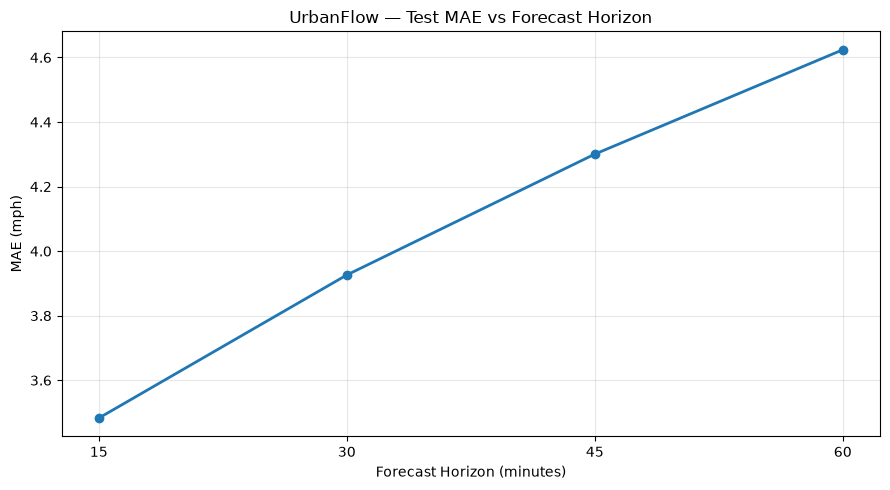

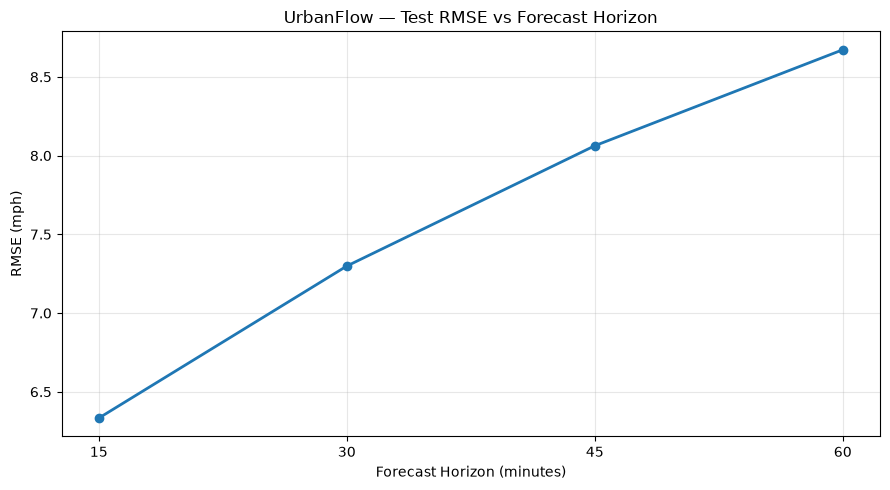


Saved:
/Users/raginigupta/Desktop/Urbanflow/results/urbanflow_test_mae_by_horizon.png
/Users/raginigupta/Desktop/Urbanflow/results/urbanflow_test_rmse_by_horizon.png
VISUALIZATION COMPLETE


In [16]:

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("URBANFLOW — FINAL PERFORMANCE VISUALIZATION")
print("=" * 70)


test_results_path = (
    RESULTS_DIR /
    "urbanflow_final_test_results.csv"
)

test_df = pd.read_csv(test_results_path)


plt.figure(figsize=(9, 5))

plt.plot(
    test_df["horizon_min"],
    test_df["MAE_mph"],
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("MAE (mph)")
plt.title("UrbanFlow — Test MAE vs Forecast Horizon")
plt.xticks(test_df["horizon_min"])
plt.grid(True, alpha=0.3)

plt.tight_layout()

mae_plot_path = (
    RESULTS_DIR /
    "urbanflow_test_mae_by_horizon.png"
)

plt.savefig(
    mae_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(9, 5))

plt.plot(
    test_df["horizon_min"],
    test_df["RMSE_mph"],
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("RMSE (mph)")
plt.title("UrbanFlow — Test RMSE vs Forecast Horizon")
plt.xticks(test_df["horizon_min"])
plt.grid(True, alpha=0.3)

plt.tight_layout()

rmse_plot_path = (
    RESULTS_DIR /
    "urbanflow_test_rmse_by_horizon.png"
)

plt.savefig(
    rmse_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(mae_plot_path)
print(rmse_plot_path)

print("=" * 70)
print("VISUALIZATION COMPLETE")
print("=" * 70)

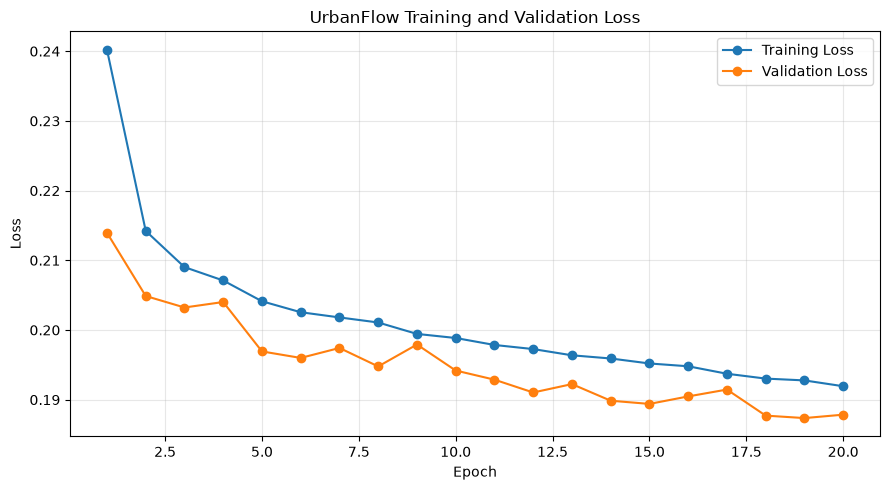

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(
    RESULTS_DIR / "urbanflow_final_training_history.csv"
)

plt.figure(figsize=(9, 5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("UrbanFlow Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "urbanflow_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

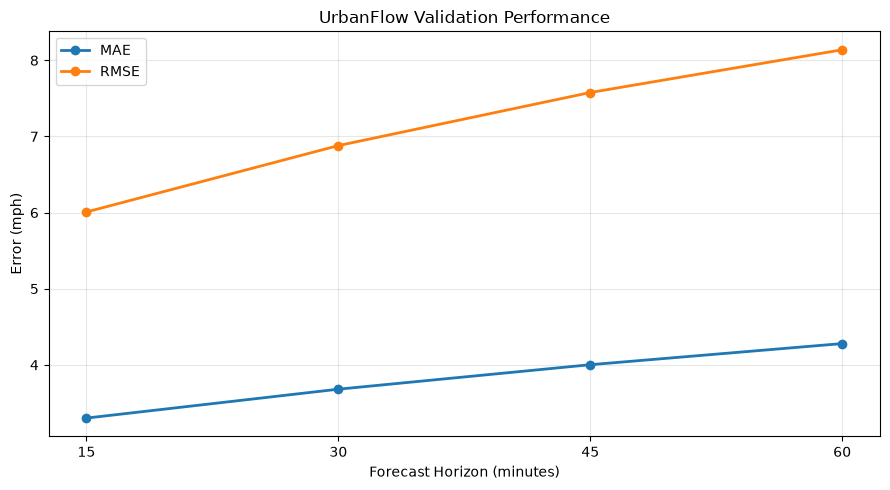

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv(
    RESULTS_DIR / "urbanflow_final_validation_results.csv"
)

plt.figure(figsize=(9, 5))

plt.plot(
    results["horizon_min"],
    results["MAE_mph"],
    marker="o",
    linewidth=2,
    label="MAE"
)

plt.plot(
    results["horizon_min"],
    results["RMSE_mph"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("Error (mph)")
plt.title("UrbanFlow Validation Performance")
plt.xticks(results["horizon_min"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "urbanflow_validation_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
print("UrbanFlow Final Model")
print()
print("Architecture: GNN + Transformer + Weather")
print("Forecast horizons: 15, 30, 45, 60 minutes")
print("Parameters: 311,780")
print("Best epoch: 20")
print()
print("Validation:")
for _, row in validation_results_df.iterrows():
    print(
        f"{int(row['horizon_min'])} min: "
        f"MAE {row['MAE_mph']:.4f} mph, "
        f"RMSE {row['RMSE_mph']:.4f} mph"
    )

print()
print("Test:")
for _, row in test_results_df.iterrows():
    print(
        f"{int(row['horizon_min'])} min: "
        f"MAE {row['MAE_mph']:.4f} mph, "
        f"RMSE {row['RMSE_mph']:.4f} mph"
    )

print()
print("Model:", MODEL_DIR / "urbanflow_final_gnn_transformer_weather_multihorizon.pth")
print("Validation results:", RESULTS_DIR / "urbanflow_final_validation_results.csv")
print("Test results:", RESULTS_DIR / "urbanflow_final_test_results.csv")

UrbanFlow Final Model

Architecture: GNN + Transformer + Weather
Forecast horizons: 15, 30, 45, 60 minutes
Parameters: 311,780
Best epoch: 20

Validation:
15 min: MAE 3.3014 mph, RMSE 6.0080 mph
30 min: MAE 3.6808 mph, RMSE 6.8801 mph
45 min: MAE 4.0023 mph, RMSE 7.5771 mph
60 min: MAE 4.2799 mph, RMSE 8.1387 mph

Test:
15 min: MAE 3.4828 mph, RMSE 6.3331 mph
30 min: MAE 3.9262 mph, RMSE 7.2986 mph
45 min: MAE 4.3006 mph, RMSE 8.0625 mph
60 min: MAE 4.6240 mph, RMSE 8.6722 mph

Model: /Users/raginigupta/Desktop/Urbanflow/models/urbanflow_final_gnn_transformer_weather_multihorizon.pth
Validation results: /Users/raginigupta/Desktop/Urbanflow/results/urbanflow_final_validation_results.csv
Test results: /Users/raginigupta/Desktop/Urbanflow/results/urbanflow_final_test_results.csv
